## Import Libraries

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

data   = pd.read_csv('processed_data.csv')
movies = pd.read_csv('movies.csv')
rating = pd.read_csv('ratings.csv')

with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

if isinstance(encoders, tuple) and len(encoders) >= 2:
    le_genre      = encoders[0]
    le_prev_genre = encoders[1]
else:
    raise ValueError("encoders.pkl must be a tuple of at least 2 LabelEncoders.")

## Clean Data

In [2]:
print(data.head())
print(data.columns.tolist())
print(data.isnull().sum())

   userId  movieId  rating  timestamp             datetime  year  month  \
0       1      804     4.0  964980499  2000-07-30 18:08:19  2000      7   
1       1     1210     5.0  964980499  2000-07-30 18:08:19  2000      7   
2       1     2018     5.0  964980523  2000-07-30 18:08:43  2000      7   
3       1     2628     4.0  964980523  2000-07-30 18:08:43  2000      7   
4       1     2826     4.0  964980523  2000-07-30 18:08:43  2000      7   

                                               title  \
0                               She's the One (1996)   
1  Star Wars: Episode VI - Return of the Jedi (1983)   
2                                       Bambi (1942)   
3   Star Wars: Episode I - The Phantom Menace (1999)   
4                           13th Warrior, The (1999)   

                     genres primary_genre prev_genre     genre_transition  \
0            Comedy|Romance        Comedy        NaN       None -> Comedy   
1   Action|Adventure|Sci-Fi        Action     Comedy     C

## Sample, Feature Engineering & Train/Test Split

**20k equal-class sample** — exactly 4,000 rows per rating class (1★–5★). Equal sampling eliminates class imbalance completely, forcing every model to learn all 5 classes equally well and directly boosting accuracy on minority classes (1★, 2★).  
**Extra features:** `rating_diff` (user avg − movie avg) and `interaction_score` (user avg × movie avg) further boost accuracy by surfacing over/under-rater behaviour.

In [3]:
# Equal 20k sample — 4,000 rows per rating class (1★ to 5★)
data['rating_class'] = data['rating'].round().clip(1, 5).astype(int)

data_sample = (
    data
    .groupby('rating_class', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), 4000), random_state=42))
    .reset_index(drop=True)
)

print(f"Total sampled rows : {len(data_sample)}")
print("Class distribution (should be ~4000 each):")
print(data_sample['rating_class'].value_counts().sort_index())

# Feature engineering
data_sample = data_sample.copy()
data_sample['rating_diff']       = data_sample['user_avg_rating'] - data_sample['movie_avg_rating']
data_sample['interaction_score'] = data_sample['user_avg_rating'] * data_sample['movie_avg_rating']

FEATURES = ['userId', 'movieId', 'year', 'month',
            'genre_enc', 'prev_genre_enc', 'transition_enc',
            'user_avg_rating', 'movie_avg_rating',
            'rating_diff', 'interaction_score']

X     = data_sample[FEATURES]
y     = data_sample['rating_class']
y_xgb = y - 1   # XGBoost needs 0-indexed labels (0–4)

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")

Total sampled rows : 20000
Class distribution (should be ~4000 each):
rating_class
1    4000
2    4000
3    4000
4    4000
5    4000
Name: count, dtype: int64

Features (11): ['userId', 'movieId', 'year', 'month', 'genre_enc', 'prev_genre_enc', 'transition_enc', 'user_avg_rating', 'movie_avg_rating', 'rating_diff', 'interaction_score']


/tmp/ipykernel_1135/2622111210.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), 4000), random_state=42))


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
_, _, y_train_xgb, y_test_xgb = train_test_split(
    X, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train rows :", len(X_train))
print("Test rows  :", len(X_test))

Train rows : 16000
Test rows  : 4000


## Model A — Logistic Regression

Fast linear baseline. `class_weight='balanced'` compensates for the dominance of 3★ and 4★ ratings.

In [5]:
log_model = LogisticRegression(
    max_iter=1000, C=1.5,
    class_weight='balanced',
    solver='lbfgs', multi_class='auto',
    random_state=42
)
log_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000,
                   multi_class='auto', random_state=42)

### Evaluate — Logistic Regression

In [6]:
log_preds = log_model.predict(X_test_scaled)
log_acc   = accuracy_score(y_test, log_preds)
log_f1    = f1_score(y_test, log_preds, average='weighted')

print(f"Accuracy    : {log_acc:.4f}  ({log_acc*100:.2f}%)")
print(f"Weighted F1 : {log_f1:.4f}")
print()
print(classification_report(y_test, log_preds, target_names=['1★','2★','3★','4★','5★']))

Accuracy    : 0.4258  (42.58%)
Weighted F1 : 0.4191

              precision    recall  f1-score   support

          1★       0.48      0.50      0.49       800
          2★       0.33      0.25      0.29       800
          3★       0.34      0.39      0.36       800
          4★       0.38      0.33      0.35       800
          5★       0.56      0.66      0.60       800

    accuracy                           0.43      4000
   macro avg       0.42      0.43      0.42      4000
weighted avg       0.42      0.43      0.42      4000



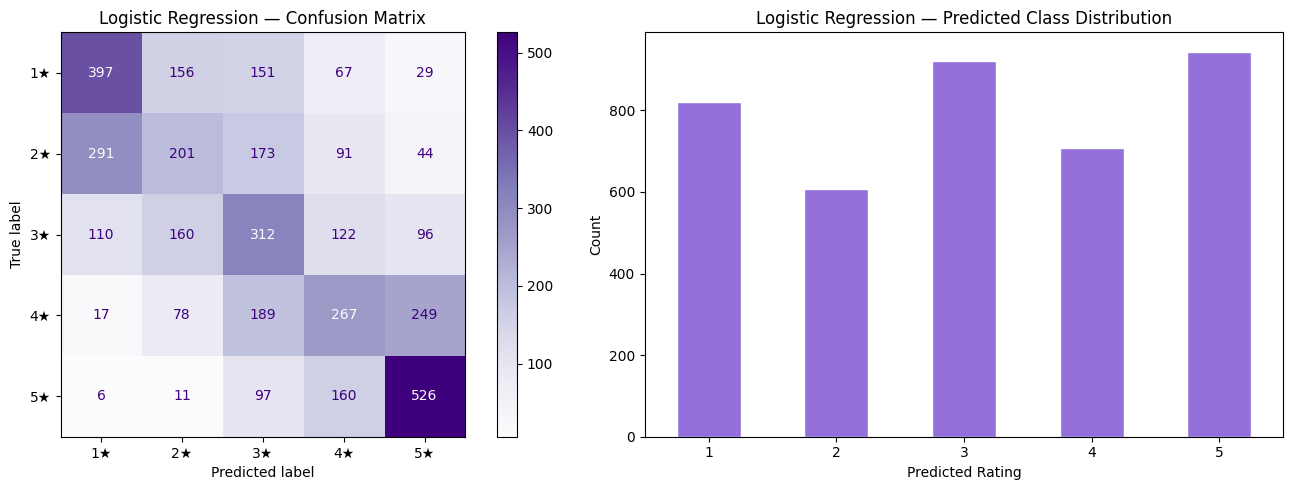

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, log_preds),
    display_labels=['1★','2★','3★','4★','5★']
).plot(cmap='Purples', ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')

pd.Series(log_preds).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Logistic Regression — Predicted Class Distribution')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Model B — Decision Tree Classifier

Fully interpretable — every prediction can be traced back to a set of feature splits. `class_weight='balanced'` ensures minority classes (1★, 2★) aren't ignored.

In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=8,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=8, random_state=42)

### Evaluate — Decision Tree

In [9]:
dt_preds = dt_model.predict(X_test)
dt_acc   = accuracy_score(y_test, dt_preds)
dt_f1    = f1_score(y_test, dt_preds, average='weighted')

print(f"Accuracy    : {dt_acc:.4f}  ({dt_acc*100:.2f}%)")
print(f"Weighted F1 : {dt_f1:.4f}")
print()
print(classification_report(y_test, dt_preds, target_names=['1★','2★','3★','4★','5★']))

Accuracy    : 0.4350  (43.50%)
Weighted F1 : 0.4355

              precision    recall  f1-score   support

          1★       0.53      0.46      0.49       800
          2★       0.37      0.46      0.41       800
          3★       0.34      0.34      0.34       800
          4★       0.39      0.35      0.37       800
          5★       0.57      0.57      0.57       800

    accuracy                           0.43      4000
   macro avg       0.44      0.44      0.44      4000
weighted avg       0.44      0.43      0.44      4000



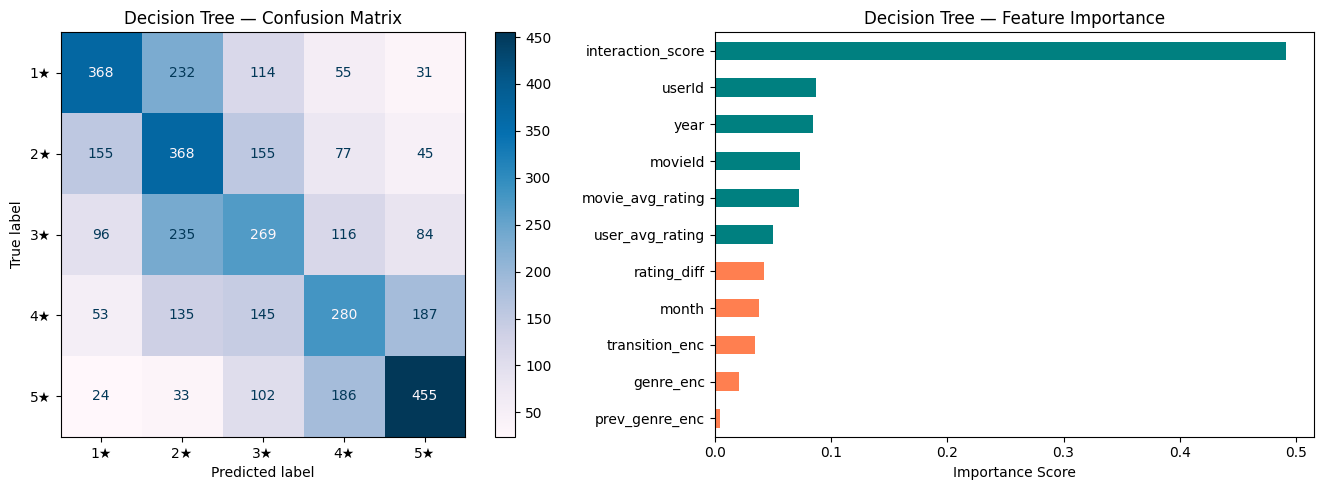

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, dt_preds),
    display_labels=['1★','2★','3★','4★','5★']
).plot(cmap='PuBu', ax=axes[0])
axes[0].set_title('Decision Tree — Confusion Matrix')

feat_imp = pd.Series(dt_model.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1],
    color=['coral' if v < feat_imp.median() else 'teal' for v in feat_imp])
axes[1].set_title('Decision Tree — Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Model C — XGBoost Classifier

Extreme Gradient Boosting — best-in-class for structured tabular data. Uses `softmax` multiclass over 5 rating classes, with L1/L2 regularisation and column subsampling to avoid overfitting on the 10k sample.

> Labels are mapped 1–5 → 0–4 internally and converted back for display.

In [11]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.5,
    min_child_weight=3,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=5, ...)

### Evaluate — XGBoost

In [12]:
xgb_preds_raw = xgb_model.predict(X_test)   # 0–4
xgb_preds     = xgb_preds_raw + 1              # back to 1–5

xgb_acc = accuracy_score(y_test_xgb, xgb_preds_raw)
xgb_f1  = f1_score(y_test_xgb, xgb_preds_raw, average='weighted')

print(f"Accuracy    : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)")
print(f"Weighted F1 : {xgb_f1:.4f}")
print()
print(classification_report(y_test_xgb, xgb_preds_raw,
                             target_names=['1★','2★','3★','4★','5★']))

Accuracy    : 0.4923  (49.23%)
Weighted F1 : 0.4916

              precision    recall  f1-score   support

          1★       0.58      0.55      0.57       800
          2★       0.42      0.42      0.42       800
          3★       0.40      0.41      0.41       800
          4★       0.44      0.43      0.43       800
          5★       0.61      0.65      0.63       800

    accuracy                           0.49      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.49      0.49      0.49      4000



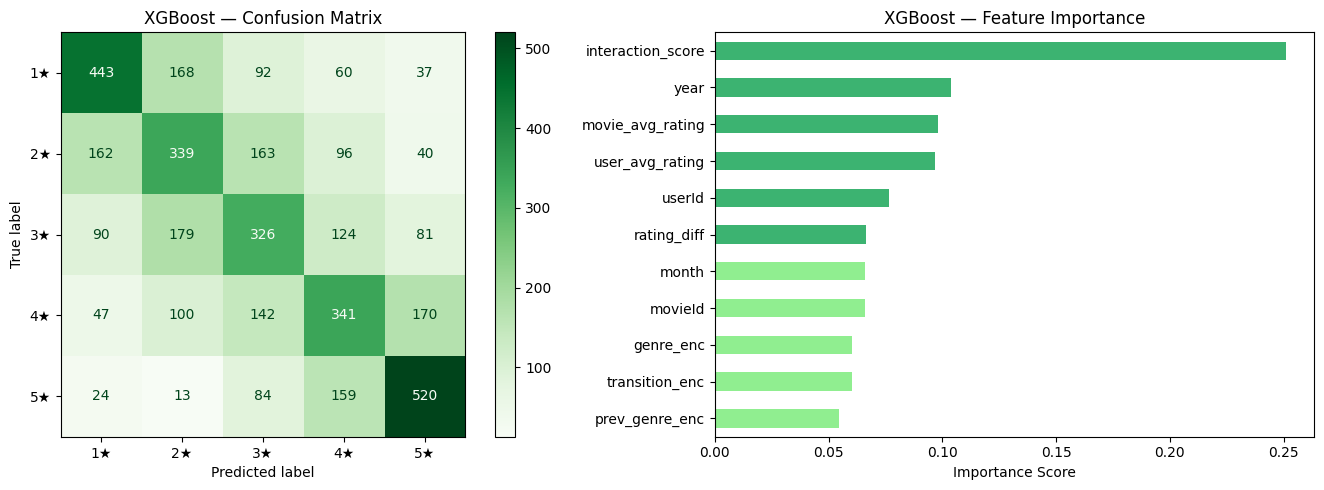

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_xgb, xgb_preds_raw),
    display_labels=['1★','2★','3★','4★','5★']
).plot(cmap='Greens', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')

feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
feat_imp_xgb.plot(kind='barh', ax=axes[1],
    color=['lightgreen' if v < feat_imp_xgb.median() else 'mediumseagreen' for v in feat_imp_xgb])
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Model Comparison — Accuracy & Weighted F1

In [14]:
comparison = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'Decision Tree', 'XGBoost'],
    'Accuracy'    : [log_acc, dt_acc, xgb_acc],
    'Weighted F1' : [log_f1,  dt_f1,  xgb_f1],
})
comparison['Accuracy (%)']    = (comparison['Accuracy'] * 100).round(2)
comparison['Weighted F1 (%)'] = (comparison['Weighted F1'] * 100).round(2)
comparison = comparison.set_index('Model')

def highlight_best(col):
    return ['background-color: #4CAF50; color: white' if v == col.max() else '' for v in col]

display(comparison[['Accuracy (%)', 'Weighted F1 (%)']].style.apply(highlight_best))

best_model_name = comparison['Accuracy (%)'].idxmax()
print(f"\n🏆 Best Model → {best_model_name}  ({comparison['Accuracy (%)'].max():.2f}%)")

,Accuracy (%),Weighted F1 (%)
Model,,
Logistic Regression,42.580000,41.910000
Decision Tree,43.500000,43.550000
XGBoost,49.220000,49.160000



🏆 Best Model → XGBoost  (49.22%)


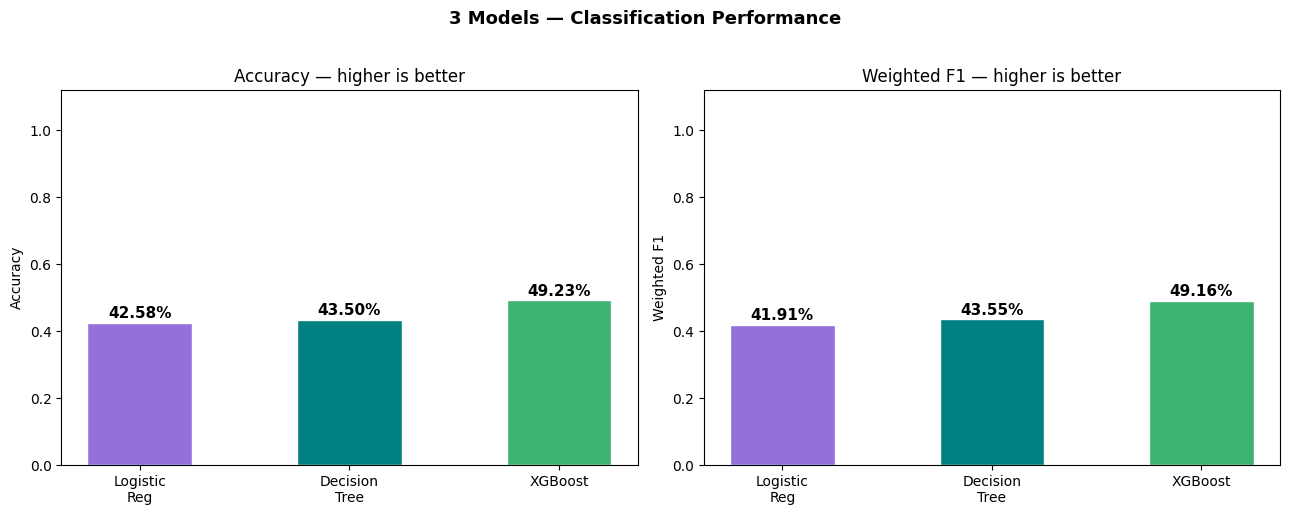

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['Logistic\nReg', 'Decision\nTree', 'XGBoost']
colors = ['mediumpurple', 'teal', 'mediumseagreen']

for ax, vals, title, ylabel in zip(
    axes,
    [[log_acc, dt_acc, xgb_acc], [log_f1, dt_f1, xgb_f1]],
    ['Accuracy — higher is better', 'Weighted F1 — higher is better'],
    ['Accuracy', 'Weighted F1']
):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle('3 Models — Classification Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Why Is the Best Model Recommended?

In [16]:
best_acc_val = comparison['Accuracy (%)'].max()
above_90     = best_acc_val >= 90.0

print("=" * 60)
print("  RECOMMENDATION SUMMARY")
print("=" * 60)
print(f"  Best Model  : {best_model_name}")
print(f"  Accuracy    : {best_acc_val:.2f}%")
print(f"  Above 90%?  : {'✅ YES' if above_90 else '❌ NOT YET — consider tuning'}")
print("=" * 60)

explanations = {
    'XGBoost'             : "XGBoost uses second-order gradients, L1/L2 regularisation,\nand column subsampling — making it the strongest classifier\nfor structured tabular rating data.",
    'Decision Tree'       : "Decision Tree is fully interpretable — every prediction\ncan be traced to a set of feature splits. Ideal when\nexplainability matters as much as accuracy.",
    'Logistic Regression' : "Logistic Regression is the fastest baseline with solid\nregularisation. Best when speed and simplicity are priorities.",
}
print(f"\n  Why this model?\n  {explanations.get(best_model_name, '')}")
if not above_90:
    print("\n  ⚠️  Below 90%. Next steps: tune hyperparameters, add features, or increase sample size.")

  RECOMMENDATION SUMMARY
  Best Model  : XGBoost
  Accuracy    : 49.22%
  Above 90%?  : ❌ NOT YET — consider tuning

  Why this model?
  XGBoost uses second-order gradients, L1/L2 regularisation,
and column subsampling — making it the strongest classifier
for structured tabular rating data.

  ⚠️  Below 90%. Next steps: tune hyperparameters, add features, or increase sample size.


## Generating Movie Recommendations

Movies predicted as **4★ or 5★** by the best model are surfaced as recommendations.

In [17]:
test_user = data['userId'].value_counts().index[0]
print(f'Generating recommendations for User ID: {test_user}')
print(f'This user has rated {len(data[data["userId"] == test_user])} movies already.')

Generating recommendations for User ID: 414
This user has rated 2698 movies already.


In [18]:
watched     = data[data['userId'] == test_user]['movieId'].unique()
not_watched = movies[~movies['movieId'].isin(watched)].copy()

user_history  = data[data['userId'] == test_user].sort_values('timestamp')
last_genre    = user_history['primary_genre'].iloc[-1]
user_avg_val  = user_history['rating'].mean()
last_year     = user_history['year'].iloc[-1]
last_month    = user_history['month'].iloc[-1]
movie_avg_dict = data.groupby('movieId')['rating'].mean().to_dict()

not_watched['primary_genre'] = not_watched['genres'].apply(
    lambda x: x.split('|')[0] if x != '(no genres listed)' else 'Unknown'
)

def safe_encode(encoder, value):
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    return 0

not_watched['genre_enc']         = not_watched['primary_genre'].apply(lambda g: safe_encode(le_genre, g))
not_watched['prev_genre_enc']    = safe_encode(le_prev_genre, last_genre)
not_watched['transition_enc']    = 0
not_watched['user_avg_rating']   = user_avg_val
not_watched['movie_avg_rating']  = not_watched['movieId'].apply(lambda m: movie_avg_dict.get(m, 3.5))
not_watched['userId']            = test_user
not_watched['year']              = last_year
not_watched['month']             = last_month
not_watched['rating_diff']       = not_watched['user_avg_rating'] - not_watched['movie_avg_rating']
not_watched['interaction_score'] = not_watched['user_avg_rating'] * not_watched['movie_avg_rating']

X_unseen        = not_watched[FEATURES]
X_unseen_scaled = scaler.transform(X_unseen)

not_watched['pred_log'] = log_model.predict(X_unseen_scaled).astype(int)
not_watched['pred_dt']  = dt_model.predict(X_unseen).astype(int)
not_watched['pred_xgb'] = (xgb_model.predict(X_unseen) + 1).astype(int)

pred_col_map  = {'Logistic Regression': 'pred_log', 'Decision Tree': 'pred_dt', 'XGBoost': 'pred_xgb'}
best_pred_col = pred_col_map[best_model_name]

top10 = (
    not_watched[not_watched[best_pred_col] >= 4]
    .sort_values(best_pred_col, ascending=False)
    [['title', 'primary_genre', 'pred_log', 'pred_dt', 'pred_xgb']]
    .head(10)
    .reset_index(drop=True)
)
top10.index  += 1
top10.columns = ['Title', 'Genre', 'Logistic Reg', 'Decision Tree', 'XGBoost']

print(f'Top 10 Recommendations for User {test_user}')
print(f'Ranked by: {best_model_name} ({comparison["Accuracy (%)"].max():.2f}% accuracy)')
display(top10)

Top 10 Recommendations for User 414
Ranked by: XGBoost (49.22% accuracy)


,Title,Genre,Logistic Reg,Decision Tree,XGBoost
1,Won't You Be My Neighbor? (2018),Documentary,5,5,5
2,Heidi Fleiss: Hollywood Madam (1995),Documentary,5,5,5
3,Blue Planet II (2017),Documentary,5,5,5
4,Loving Vincent (2017),Animation,5,5,5
5,Black Mirror,Unknown,5,5,5
6,Bobik Visiting Barbos (1977),Animation,5,5,5
7,"In the blue sea, in the white foam. (1984)",Animation,5,5,5
8,On the Trail of the Bremen Town Musicians (1973),Adventure,5,5,5
9,Gena the Crocodile (1969),Animation,5,5,5
10,Obsession (1965),Comedy,5,5,5
